# 11 - Modelado con XGBoost
Segundo modelo del estudio. A diferencia del SARIMAX, ajustado de forma independiente para cada embalse, XGBoost se entrena con un **enfoque global**: un único modelo aprende de los 17 embalses en conjunto.

## 1. Configuración y datos

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

sys.path.append("..")

DIR_PROCESSED = Path("../data/processed")
DIR_FIGURAS = Path("../outputs/figures")
DIR_RESULTADOS = Path("../outputs/tables")
DIR_FIGURAS.mkdir(parents=True, exist_ok=True)
DIR_RESULTADOS.mkdir(parents=True, exist_ok=True)

TEST_INI = pd.Timestamp("2022-01-01")
HORIZONTES = [7, 30, 90]
PARAMETROS = ["amonio_mgl", "conductividad_uscm", "oxigeno_mgl",
              "ph", "temp_agua_c", "turbidez_ntu"]

df = pd.read_parquet(DIR_PROCESSED / "dataset_modelado.parquet")
df = df.sort_values(["ID_SAIH", "fecha"]).reset_index(drop=True)
experimentales = sorted(df["ID_SAIH"].unique())

print(f"Observaciones: {len(df):,} | embalses: {len(experimentales)}")
print(f"Periodo: {df['fecha'].min():%Y-%m-%d} a {df['fecha'].max():%Y-%m-%d}")

Observaciones: 111,758 | embalses: 17
Periodo: 2006-01-01 a 2023-12-31


## 2. Definición de variables predictoras y escenarios
Se emplean todas las variables derivadas de la ingeniería.
El escenario **base** reúne las variables hidrológicas, meteorológicas y temporales.
El escenario **base+calidad** añade los seis parámetros de calidad del agua.

In [2]:
OBJETIVOS = ["objetivo_h7", "objetivo_h30", "objetivo_h90"]
META = ["fecha", "ID_SAIH", "Nombre_SAIH", "Sistema", "pct_llenado", "volumen_hm3"]
CALIDAD = [f"cal_{p}" for p in PARAMETROS]

# Identidad del embalse: identificador codificado (one-hot) + capacidad (tamaño)
df_id = pd.get_dummies(df["ID_SAIH"], prefix="emb").astype(int)
COLS_ID = list(df_id.columns)
df = pd.concat([df, df_id], axis=1)

FEATURES_BASE = [c for c in df.columns
                 if c not in OBJETIVOS + META + CALIDAD + COLS_ID]
FEATURES_BASE = list(dict.fromkeys(FEATURES_BASE + COLS_ID))

ESCENARIOS = {
    "base": FEATURES_BASE,
    "base_calidad": FEATURES_BASE + CALIDAD,
}

for nombre, cols in ESCENARIOS.items():
    faltan = [c for c in cols if c not in df.columns]
    print(f"{nombre}: {len(cols)} predictoras" + (f"  AVISO faltan: {faltan}" if faltan else ""))
print(f"\n(incluye {len(COLS_ID)} columnas de identificador de embalse)")
print(f"Predictoras base (sin identificador): {[c for c in FEATURES_BASE if c not in COLS_ID]}")

base: 65 predictoras
base_calidad: 71 predictoras

(incluye 17 columnas de identificador de embalse)
Predictoras base (sin identificador): ['aportacion_m3s', 'salida_m3s', 'aemet_temp_media_c', 'aemet_temp_min_c', 'aemet_temp_max_c', 'aemet_precipitacion_mm', 'aemet_humedad_pct', 'Capacidad_hm3', 'pct_llenado_lag1', 'pct_llenado_lag7', 'pct_llenado_lag30', 'pct_llenado_ma7', 'pct_llenado_ma30', 'pct_llenado_ma90', 'aportacion_m3s_lag1', 'aportacion_m3s_lag7', 'aportacion_m3s_lag30', 'aportacion_m3s_ma7', 'aportacion_m3s_ma30', 'aportacion_m3s_ma90', 'salida_m3s_lag1', 'salida_m3s_lag7', 'salida_m3s_lag30', 'salida_m3s_ma7', 'salida_m3s_ma30', 'salida_m3s_ma90', 'aemet_precipitacion_mm_lag1', 'aemet_precipitacion_mm_lag7', 'aemet_precipitacion_mm_lag30', 'aemet_precipitacion_mm_ma7', 'aemet_precipitacion_mm_ma30', 'aemet_precipitacion_mm_ma90', 'aemet_temp_media_c_lag1', 'aemet_temp_media_c_lag7', 'aemet_temp_media_c_lag30', 'aemet_temp_media_c_ma7', 'aemet_temp_media_c_ma30', 'aemet_te

## 3. Métricas y partición
RMSE, MAE y NSE

In [3]:
def metricas(y_real, y_pred):
    """RMSE, MAE y coeficiente de eficiencia de Nash-Sutcliffe."""
    y_real, y_pred = np.asarray(y_real), np.asarray(y_pred)
    m = ~(np.isnan(y_real) | np.isnan(y_pred))
    y_real, y_pred = y_real[m], y_pred[m]
    if len(y_real) == 0:
        return {"n": 0, "rmse": np.nan, "mae": np.nan, "nse": np.nan}
    err = y_real - y_pred
    sst = ((y_real - y_real.mean()) ** 2).sum()
    return {
        "n": len(y_real),
        "rmse": np.sqrt((err ** 2).mean()),
        "mae": np.abs(err).mean(),
        "nse": 1 - (err ** 2).sum() / sst if sst > 0 else np.nan,
    }

## 4. Baseline de persistencia


In [4]:
def persistencia_sobre_muestra(df, meta_test, horizonte):
    """NSE, RMSE y MAE de la persistencia, evaluada EXACTAMENTE sobre las mismas
    observaciones de test que los modelos (las de meta_test: pares embalse-fecha).
    La predicción persistente a horizonte h es el llenado observado en la fecha de
    origen (h días antes de la fecha objetivo)."""
    # Índice de llenado por (embalse, fecha) para buscar el valor en el origen
    llenado = df.set_index(["ID_SAIH", "fecha"])["pct_llenado"]
    filas = []
    for emb, g in meta_test.groupby("ID_SAIH"):
        reales, preds = [], []
        for fecha_obj in g["fecha"]:
            # fecha_obj es la fecha del objetivo (t+h); el origen es t = fecha_obj - h
            fecha_origen = fecha_obj - pd.Timedelta(days=horizonte)
            try:
                real = llenado.loc[(emb, fecha_obj)]
                pred = llenado.loc[(emb, fecha_origen)]
            except KeyError:
                continue
            reales.append(real)
            preds.append(pred)
        m = metricas(np.array(reales), np.array(preds))
        filas.append({"embalse": emb, "horizonte": horizonte, "escenario": "persistencia", **m})
    return filas

## 5. Entrenamiento y evaluación
Se entrena un modelo XGBoost por horizonte y escenario (seis en total) con unaconfiguración estándar. Las métricas se calculan **por embalse** sobre el test.

In [5]:
PARAMS = dict(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    n_jobs=-1,
)

resultados = []
predicciones = []
modelos = {}   # (horizonte, escenario) -> modelo entrenado, para SHAP

for h in HORIZONTES:
    objetivo = f"objetivo_h{h}"
    # Muestra común: filas válidas para el escenario más exigente (base+calidad).
    # Se incluye pct_llenado (llenado en el origen) para calcular la persistencia
    # sobre EXACTAMENTE las mismas observaciones que los modelos.
    cols_exigente = ESCENARIOS["base_calidad"] + [objetivo, "ID_SAIH", "fecha", "pct_llenado"]
    d = df[cols_exigente].dropna(subset=ESCENARIOS["base_calidad"] + [objetivo]).reset_index(drop=True)

    # Tres zonas temporales:
    #   train: fecha < TEST_INI - h  (embargo: se excluyen las filas cuyo objetivo caería en el test)
    #   embargo: entre TEST_INI - h y TEST_INI (se descarta, ni train ni test)
    #   test: fecha >= TEST_INI
    fin_train = TEST_INI - pd.Timedelta(days=h)
    es_train = (d["fecha"] < fin_train).values
    es_test = (d["fecha"] >= TEST_INI).values
    meta = d[["ID_SAIH", "fecha"]]

    # Persistencia sobre la muestra común de test: predicción = llenado en el origen
    res_p = meta[es_test].copy()
    res_p["real"] = d.loc[es_test, objetivo].values
    res_p["pred"] = d.loc[es_test, "pct_llenado"].values
    for emb, g in res_p.groupby("ID_SAIH"):
        resultados.append({"embalse": emb, "horizonte": h, "escenario": "persistencia",
                           **metricas(g["real"], g["pred"])})

    for nombre, features in ESCENARIOS.items():
        X = d[features]
        y = d[objetivo]

        Xtr, ytr = X[es_train], y[es_train]
        Xte, yte = X[es_test], y[es_test]
        meta_te = meta[es_test].reset_index(drop=True)

        model = XGBRegressor(**PARAMS)
        model.fit(Xtr, ytr)
        pred = model.predict(Xte)

        modelos[(h, nombre)] = (model, Xte.reset_index(drop=True), meta_te)

        res_te = meta_te.copy()
        res_te["real"] = yte.values
        res_te["pred"] = pred
        for emb, g in res_te.groupby("ID_SAIH"):
            m = metricas(g["real"], g["pred"])
            resultados.append({"embalse": emb, "horizonte": h, "escenario": nombre, **m})
        predicciones.append(res_te.assign(horizonte=h, escenario=nombre))
        print(f"  h{h} {nombre}: entrenado ({len(Xtr):,} train / {len(Xte):,} test)")

resultados = pd.DataFrame(resultados)
resultados.to_parquet(DIR_RESULTADOS / "xgboost_metricas.parquet", index=False)
pd.concat(predicciones).to_parquet(DIR_RESULTADOS / "xgboost_predicciones.parquet", index=False)

print("\n=== Mediana por horizonte y escenario ===")
print(resultados.groupby(["horizonte", "escenario"])[["rmse", "mae", "nse"]]
      .median().round(3).to_string())

  h7 base: entrenado (97,624 train / 12,291 test)
  h7 base_calidad: entrenado (97,624 train / 12,291 test)
  h30 base: entrenado (97,233 train / 11,900 test)
  h30 base_calidad: entrenado (97,233 train / 11,900 test)
  h90 base: entrenado (96,213 train / 10,880 test)
  h90 base_calidad: entrenado (96,213 train / 10,880 test)

=== Mediana por horizonte y escenario ===
                          rmse    mae    nse
horizonte escenario                         
7         base           4.360  3.266  0.627
          base_calidad   4.458  3.193  0.638
          persistencia   4.420  2.877  0.634
30        base           7.623  5.845 -0.154
          base_calidad   7.800  5.818 -0.037
          persistencia   8.122  6.062 -0.410
90        base          10.103  8.198 -0.165
          base_calidad  10.579  7.977 -0.206
          persistencia  11.129  8.974 -0.891


## 6. Comparación con la persistencia
Número de embalses en los que XGBoost (escenario base) supera a la persistencia,por horizonte.

In [6]:
for h in HORIZONTES:
    r = resultados[resultados["horizonte"] == h].pivot_table(
        index="embalse", columns="escenario", values="nse")
    mejora = (r["base"] > r["persistencia"]).sum()
    print(f"h={h}: XGBoost base supera a persistencia en {mejora}/17 embalses")

h=7: XGBoost base supera a persistencia en 11/17 embalses
h=30: XGBoost base supera a persistencia en 14/17 embalses
h=90: XGBoost base supera a persistencia en 13/17 embalses


## 7. Interpretabilidad con SHAP
Se examina el horizonte de 30 días como caso representativo.

In [7]:
import shap

H_SHAP = 30
model, Xte, meta_te = modelos[(H_SHAP, "base_calidad")]

# Submuestra del test para acelerar el cálculo (SHAP es costoso)
rng = np.random.RandomState(42)
idx = rng.choice(len(Xte), size=min(3000, len(Xte)), replace=False)
X_shap = Xte.iloc[idx]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

# Importancia global: media del valor absoluto por variable
imp = (pd.Series(np.abs(shap_values).mean(axis=0), index=X_shap.columns)
       .sort_values(ascending=False))

print(f"SHAP - horizonte {H_SHAP} días, escenario base+calidad")
print("\nTop 15 variables por importancia media |SHAP|:")
print(imp.head(15).round(4).to_string())

print("\nImportancia de las variables de calidad:")
for c in CALIDAD:
    pos = list(imp.index).index(c) + 1
    print(f"  {c:<26} {imp[c]:.4f}   (puesto {pos} de {len(imp)})")

SHAP - horizonte 30 días, escenario base+calidad

Top 15 variables por importancia media |SHAP|:
pct_llenado_lag1           11.6115
pct_llenado_ma7             4.8662
aportacion_m3s_ma90         1.1999
pct_llenado_ma30            0.9459
anio_hidrologico            0.7703
aportacion_m3s              0.7572
salida_m3s                  0.7547
aemet_temp_media_c_ma30     0.6778
dia_anio_cos                0.6254
Capacidad_hm3               0.5987
emb_E011                    0.5757
aportacion_m3s_ma30         0.5120
aemet_temp_media_c_ma90     0.4927
pct_llenado_ma90            0.4926
pct_llenado_lag30           0.4424

Importancia de las variables de calidad:
  cal_amonio_mgl             0.1010   (puesto 45 de 71)
  cal_conductividad_uscm     0.1847   (puesto 35 de 71)
  cal_oxigeno_mgl            0.2547   (puesto 25 de 71)
  cal_ph                     0.2271   (puesto 29 de 71)
  cal_temp_agua_c            0.2147   (puesto 30 de 71)
  cal_turbidez_ntu           0.0598   (puesto 56 de 71)


In [8]:
# Comparación del peso de la calidad en los tres horizontes (escenario base+calidad)
resumen_calidad = []

for h in HORIZONTES:
    model_h, Xte_h, _ = modelos[(h, "base_calidad")]
    idx_h = rng.choice(len(Xte_h), size=min(3000, len(Xte_h)), replace=False)
    X_h = Xte_h.iloc[idx_h]

    expl_h = shap.TreeExplainer(model_h)
    sv_h = expl_h.shap_values(X_h)
    imp_h = pd.Series(np.abs(sv_h).mean(axis=0), index=X_h.columns)

    fila = {"horizonte": h}
    for c in CALIDAD:
        fila[c] = round(imp_h[c], 4)
    fila["calidad_total"] = round(imp_h[CALIDAD].sum(), 4)
    fila["peso_calidad_%"] = round(100 * imp_h[CALIDAD].sum() / imp_h.sum(), 2)
    # Mejor puesto de una variable de calidad
    ranking = imp_h.sort_values(ascending=False).index.tolist()
    mejor_cal = min(CALIDAD, key=lambda c: ranking.index(c))
    fila["mejor_cal"] = mejor_cal
    fila["mejor_puesto"] = ranking.index(mejor_cal) + 1
    resumen_calidad.append(fila)

resumen_calidad = pd.DataFrame(resumen_calidad).set_index("horizonte")
print("Peso de la calidad por horizonte (escenario base+calidad):\n")
print(resumen_calidad.to_string())

Peso de la calidad por horizonte (escenario base+calidad):

           cal_amonio_mgl  cal_conductividad_uscm  cal_oxigeno_mgl  cal_ph  cal_temp_agua_c  cal_turbidez_ntu  calidad_total  peso_calidad_%        mejor_cal  mejor_puesto
horizonte                                                                                                                                                                  
7                  0.0422                  0.0677           0.0624  0.1229           0.0644            0.0257         0.3853            1.27           cal_ph            25
30                 0.1095                  0.1789           0.2592  0.2299           0.2150            0.0608         1.0532            3.16  cal_oxigeno_mgl            25
90                 0.0500                  0.3603           0.3835  0.3357           0.1254            0.2012         1.4562            3.98  cal_oxigeno_mgl            22


### Visualización: importancia media y resumen de efectos

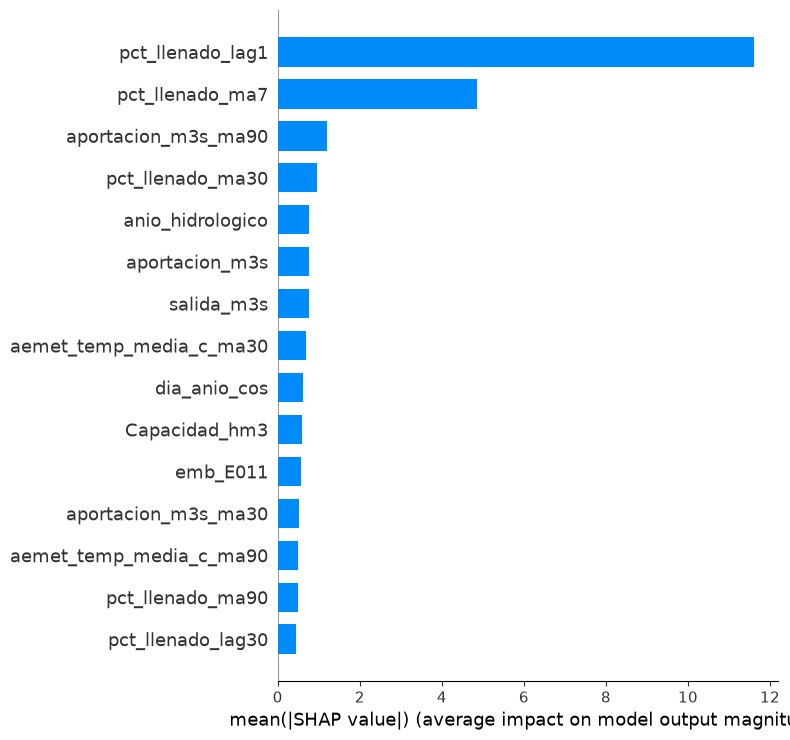

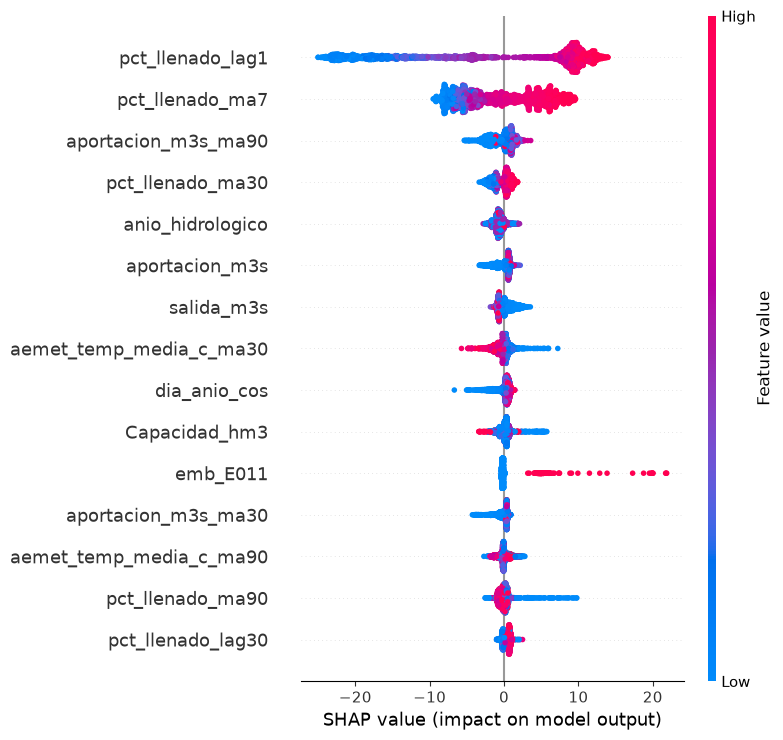

In [9]:
# Bar plot de importancia media
fig = plt.figure()
shap.summary_plot(shap_values, X_shap, plot_type="bar", max_display=15, show=False)
plt.tight_layout()
plt.savefig(DIR_FIGURAS / f"5_5_shap_importancia_h{H_SHAP}.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary plot (efecto y dirección)
fig = plt.figure()
shap.summary_plot(shap_values, X_shap, max_display=15, show=False)
plt.tight_layout()
plt.savefig(DIR_FIGURAS / f"5_5_shap_resumen_h{H_SHAP}.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Importancia agregada de la calidad frente al resto
Para cuantificar de forma sintética el peso del bloque de calidad, se compara la importancia SHAP acumulada de las seis variables de calidad frente al total.

In [16]:
imp_calidad = imp[CALIDAD].sum()
imp_total = imp.sum()
print(f"Importancia SHAP acumulada de la calidad: {imp_calidad:.4f}")
print(f"Importancia SHAP total: {imp_total:.4f}")
print(f"Peso relativo de la calidad: {100*imp_calidad/imp_total:.2f}%")

Importancia SHAP acumulada de la calidad: 1.0420
Importancia SHAP total: 33.2674
Peso relativo de la calidad: 3.13%


## Tablas de resultados para la memoria


In [11]:
# --- Tablas de métricas para la memoria ---
met = pd.read_parquet(DIR_RESULTADOS / "xgboost_metricas.parquet")

NOMBRES = {
    "E002": "E002 · Os Peares", "E008": "E008 · Fuente del Azufre", "E009": "E009 · Montearenas",
    "E011": "E011 · Peñarrubia", "E025": "E025 · Leboreiro Mao", "E026": "E026 · Edrada Mao",
    "E027": "E027 · San Esteban", "E028": "E028 · Vilasouto", "E029": "E029 · San Pedro",
    "E030": "E030 · Velle", "E031": "E031 · Castrelo", "E033": "E033 · Frieira",
    "E07A": "E07A · Bárcena", "E32A": "E32A · Albarellos", "E35A": "E35A · Conchas",
    "E570": "E570 · Santiago", "E571": "E571 · Pumares",
}
ESC = {"base": "Base", "base_calidad": "Base + calidad", "persistencia": "Persistencia"}

# Tabla 1: medianas por horizonte y escenario
t1 = (met.groupby(["horizonte", "escenario"])[["rmse", "mae", "nse"]]
        .median().round(3).reset_index())
t1["escenario"] = t1["escenario"].map(ESC)
t1.columns = ["Horizonte", "Escenario", "RMSE", "MAE", "NSE"]
t1.to_csv(DIR_RESULTADOS / "xgboost_t1_medianas.csv", index=False)

# Tablas 2-4: NSE por embalse en cada horizonte
def tabla_embalse(h):
    t = (met[met["horizonte"] == h]
         .pivot_table(index="embalse", columns="escenario", values="nse")
         .round(3)[["base", "base_calidad", "persistencia"]])
    t.loc["Mediana"] = t.median().round(3)
    t.index = [NOMBRES.get(e, e) for e in t.index]
    t.columns = [ESC[c] for c in t.columns]
    t.to_csv(DIR_RESULTADOS / f"xgboost_nse_h{h}.csv")
    return t

print("TABLA 1 — Medianas por horizonte y escenario (XGBoost)")
print(t1.to_markdown(index=False))
for h in [7, 30, 90]:
    print(f"\nTABLA — NSE por embalse (horizonte {h} días)")
    print(tabla_embalse(h).to_markdown())

TABLA 1 — Medianas por horizonte y escenario (XGBoost)
|   Horizonte | Escenario      |   RMSE |   MAE |    NSE |
|------------:|:---------------|-------:|------:|-------:|
|           7 | Base           |  4.36  | 3.266 |  0.627 |
|           7 | Base + calidad |  4.458 | 3.193 |  0.638 |
|           7 | Persistencia   |  4.42  | 2.877 |  0.634 |
|          30 | Base           |  7.623 | 5.845 | -0.154 |
|          30 | Base + calidad |  7.8   | 5.818 | -0.037 |
|          30 | Persistencia   |  8.122 | 6.062 | -0.41  |
|          90 | Base           | 10.103 | 8.198 | -0.165 |
|          90 | Base + calidad | 10.579 | 7.977 | -0.206 |
|          90 | Persistencia   | 11.129 | 8.974 | -0.891 |

TABLA — NSE por embalse (horizonte 7 días)
|                          |   Base |   Base + calidad |   Persistencia |
|:-------------------------|-------:|-----------------:|---------------:|
| E002 · Os Peares         |  0.632 |            0.638 |          0.634 |
| E008 · Fuente del Azufre | -

In [12]:
# Guardar la tabla de peso de la calidad por horizonte (del análisis SHAP)
resumen_calidad.to_csv(DIR_RESULTADOS / "xgboost_shap_peso_calidad.csv")
print("Tabla de peso de calidad por horizonte guardada.")
print(resumen_calidad[["calidad_total", "peso_calidad_%", "mejor_cal", "mejor_puesto"]].to_string())

Tabla de peso de calidad por horizonte guardada.
           calidad_total  peso_calidad_%        mejor_cal  mejor_puesto
horizonte                                                              
7                 0.3853            1.27           cal_ph            25
30                1.0532            3.16  cal_oxigeno_mgl            25
90                1.4562            3.98  cal_oxigeno_mgl            22
